In [62]:
from datetime import datetime, timedelta
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import data, db
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

In [31]:
heatwave_date = datetime.fromisoformat("2025-07-27")

In [22]:
num_income_groups = 4
block_groups = con.sql("""
    SELECT * EXCLUDE (GEOM),
           ST_AsWKB(GEOM) AS geometry
    FROM block_groups
    WHERE MSA_CODE = 'C4530'
""").pl().with_columns(
    pl.col("MEDIAN_HH_INCOME")
      .qcut(num_income_groups, labels=[str(i) for i in range(1, num_income_groups + 1)], allow_duplicates=True)
      .cast(pl.Utf8)
      .alias("income_decile")
)
block_groups

GEOID,OGC_FID,STATEFP,COUNTYFP,MSA_CODE,MSA_NAME,MEDIAN_HH_INCOME,MEDIAN_HH_INCOME_MOE,geometry,income_decile
str,i64,str,str,str,str,f64,f64,binary,str
"""121030251232""",187,"""12""","""103""","""C4530""","""Tampa-St. Petersburg-Clearwate…",64000.0,23785.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x009\x00\x00\x00Y\x13\x0b|E\xb5T\xc0\xa5\x9fpvk\xdd;@\xe8\x9f\xe0bE\xb5T\xc0\xda\xe6\xc6\xf4\x84\xdd;@0fKVE\xb5T\xc0\xc6\x19\xc3\x9c\xa0\xdd;""…","""2"""
"""121030250152""",199,"""12""","""103""","""C4530""","""Tampa-St. Petersburg-Clearwate…",53309.0,11219.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00X\x00\x00\x00\x1dV\xb8\xe5#\xb0T\xc0\xdc\xba\x9b\xa7:\xd4;@\x87\x16\xd9\xce\xf7\xafT\xc0V\xefp;4\xd4;@\xb5\x15\xfb\xcb\xee\xafT\xc0\x04\xc9;\x872\xd4;""…","""1"""
"""121030251093""",200,"""12""","""103""","""C4530""","""Tampa-St. Petersburg-Clearwate…",52625.0,22219.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00?\x00\x00\x00c\x09kc\xec\xb2T\xc0\x80bd\xc9\x1c\xd3;@\xe3\xe0\xd21\xe7\xb2T\xc0H\xdcc\xe9C\xd3;@\xe9\xb7\xaf\x03\xe7\xb2T\xc0\x98OV\x0cW\xd3;""…","""1"""
"""121030253052""",201,"""12""","""103""","""C4530""","""Tampa-St. Petersburg-Clearwate…",58452.0,5934.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00l\x00\x00\x00\x06\xf6\x98Hi\xb2T\xc0\x87\x88\x9bS\xc9\xe8;@7\x8eX\x8bO\xb2T\xc0\xc3\xba\xf1\xee\xc8\xe8;@\xae\x9bR^+\xb2T\xc0vQ\xf4\xc0\xc7\xe8;""…","""2"""
"""121030254152""",202,"""12""","""103""","""C4530""","""Tampa-St. Petersburg-Clearwate…",33125.0,13490.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00&\x00\x00\x00\x1c\xcfg@\xbd\xafT\xc0M\xd7\x13]\x17\xea;@:\xe8\x12\x0e\xbd\xafT\xc0J$\xd1\xcb(\xea;@X\x01\xbe\xdb\xbc\xafT\xc0/\x15\x1b\xf3:\xea;""…","""1"""
…,…,…,…,…,…,…,…,…,…
"""120570001012""",13383,"""12""","""057""","""C4530""","""Tampa-St. Petersburg-Clearwate…",63664.0,5217.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x006\x00\x00\x00X\xa85\xcd;\x9aT\xc0\xe8\xbb[Y\xa2\x0b<@X\xa85\xcd;\x9aT\xc0\xd7\xa6\xb1\xbd\x16\x0c<@$d\x20\xcf.\x9aT\xc00\xf2\xb2&\x16\x0c<""…","""2"""
"""120570004012""",13384,"""12""","""057""","""C4530""","""Tampa-St. Petersburg-Clearwate…",21691.0,1572.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00""\x00\x00\x00\xe8\xfa>\x1c$\x9dT\xc0\x0c\x01\xc0\xb1g\x0b<@_EF\x07$\x9dT\xc0\xfa\xf2\x02\xec\xa3\x0b<@e\x1c#\xd9#\x9dT\xc03\xdf\xc1O\x1c\x0c<""…","""1"""
"""120570004013""",13385,"""12""","""057""","""C4530""","""Tampa-St. Petersburg-Clearwate…",69056.0,3300.0,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x1b\x00\x00\x00\xdf\xc2\xba\xf1\xee\x9dT\xc0f\xf5\x0e\xb7C\x0b<@\xfd\xdbe\xbf\xee\x9dT\xc0I,)w\x9f\x0b<@\\xe4\x9e\xae\xee\x9dT\xc0\xe5_\xcb+\xd7\x0b<""…","""2"""


In [23]:
pdf = block_groups.to_pandas()
geo_block_groups = gpd.GeoDataFrame(
    pdf.drop(columns="geometry"),
    geometry=gpd.GeoSeries.from_wkb(pdf["geometry"].apply(bytes), crs="EPSG:4269"),
)

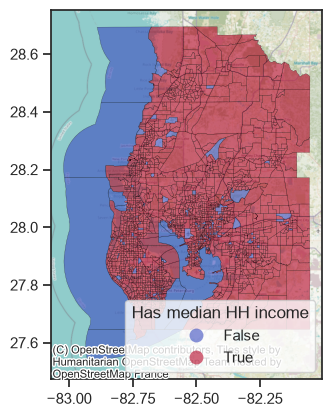

In [24]:
geo_block_groups["has_hh"] = geo_block_groups["MEDIAN_HH_INCOME"].notna()
ax = geo_block_groups.plot(
    column="has_hh",
    categorical=True,
    cmap="coolwarm",
    alpha=0.6,
    edgecolor="black",
    linewidth=0.2,
    legend=True,
    legend_kwds={"title": "Has median HH income", "loc": "lower right"}
)
cx.add_basemap(ax=ax, zoom=10, crs="EPSG:4269")

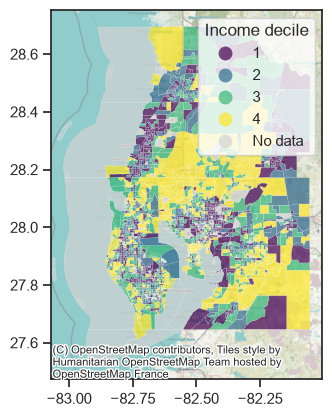

In [25]:
ax = geo_block_groups.plot(
    column="income_decile",
    categorical=True,
    cmap="viridis",
    alpha=0.7,
    edgecolor="white",
    linewidth=0.15,
    legend=True,
    legend_kwds={"title": "Income decile", "loc": "upper right"},
    missing_kwds={"color": "lightgray", "label": "No data"},
)
cx.add_basemap(ax=ax, zoom=10, crs="EPSG:4269")

## POI visits in :area:

In [36]:
visits = con.sql("""
    SELECT 
        MSA_CODE,
        GEOID,
        COUNT(DISTINCT p.ID_STORE) AS POIS,
        SUM(VISITOR_COUNTS) AS VISITOR_COUNTS,
        AVG(DISTANCE_FROM_HOME) AS AVG_DISTANCE_FROM_HOME
    FROM block_groups bg
    JOIN pois p ON bg.GEOID = p.POI_GEOID
    JOIN visits v ON v.ID_STORE = p.ID_STORE
    WHERE MSA_CODE = 'C4530'
    GROUP BY 1, 2
""").pl()
visits

MSA_CODE,GEOID,POIS,VISITOR_COUNTS,AVG_DISTANCE_FROM_HOME
str,str,i64,"decimal[38,0]",f64
"""C4530""","""120530416011""",10,410411,16429.439883
"""C4530""","""121030201061""",55,2334030,45708.573684
"""C4530""","""120570121073""",67,7801905,9645.841372
"""C4530""","""120570141191""",35,1451858,22977.769866
"""C4530""","""120570115161""",40,2464078,9503.709287
…,…,…,…,…
"""C4530""","""121030267043""",8,234993,9386.133987
"""C4530""","""120570028003""",7,58286,10008.688889
"""C4530""","""120570140122""",3,336131,17462.302817


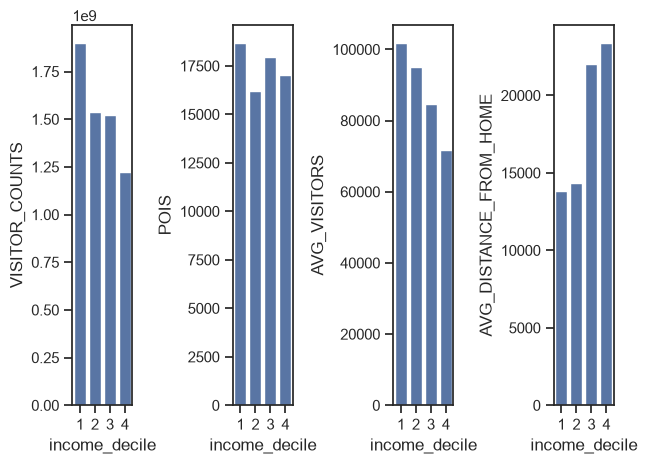

In [39]:
agg = visits.join(block_groups, on="GEOID").group_by("income_decile").agg(
    pl.col("POIS").sum(),
    pl.col("VISITOR_COUNTS").sum(),
    ((pl.col("AVG_DISTANCE_FROM_HOME") * pl.col("VISITOR_COUNTS")).sum() / pl.col("VISITOR_COUNTS").sum()).alias("AVG_DISTANCE_FROM_HOME")
).with_columns(
    (pl.col("VISITOR_COUNTS") / pl.col("POIS")).alias("AVG_VISITORS")
).sort("income_decile")

fig, axes = plt.subplots(1, 4)
sns.barplot(agg, x="income_decile", y="VISITOR_COUNTS", ax=axes[0])
sns.barplot(agg, x="income_decile", y="POIS", ax=axes[1])
sns.barplot(agg, x="income_decile", y="AVG_VISITORS", ax=axes[2])
sns.barplot(agg, x="income_decile", y="AVG_DISTANCE_FROM_HOME", ax=axes[3])
fig.tight_layout()

In [33]:
visits_dt = con.sql("""
    SELECT 
        MSA_CODE,
        GEOID,
        DATE_RANGE_START,
        SUM(VISITOR_COUNTS) AS VISITOR_COUNTS,
        AVG(DISTANCE_FROM_HOME) AS AVG_DISTANCE_FROM_HOME
    FROM block_groups bg
    JOIN pois p ON bg.GEOID = p.POI_GEOID
    JOIN visits v ON v.ID_STORE = p.ID_STORE
    WHERE MSA_CODE = 'C4530'
    GROUP BY 1, 2, 3
""").pl()
visits_dt

MSA_CODE,GEOID,DATE_RANGE_START,VISITOR_COUNTS,AVG_DISTANCE_FROM_HOME
str,str,datetime[μs],"decimal[38,0]",f64
"""C4530""","""120530410052""",2025-01-06 00:00:00,398971,9172.466667
"""C4530""","""120570057004""",2025-01-06 00:00:00,234975,16427.054945
"""C4530""","""120570121063""",2025-01-06 00:00:00,22573,9820.681818
"""C4530""","""120570027011""",2025-01-06 00:00:00,116710,13410.947368
"""C4530""","""121030268201""",2025-01-06 00:00:00,133369,11821.887097
…,…,…,…,…
"""C4530""","""120530404001""",2025-05-12 00:00:00,368,89.0
"""C4530""","""120530404001""",2025-05-19 00:00:00,367,3601.0
"""C4530""","""120530404001""",2025-02-03 00:00:00,466,11480.0


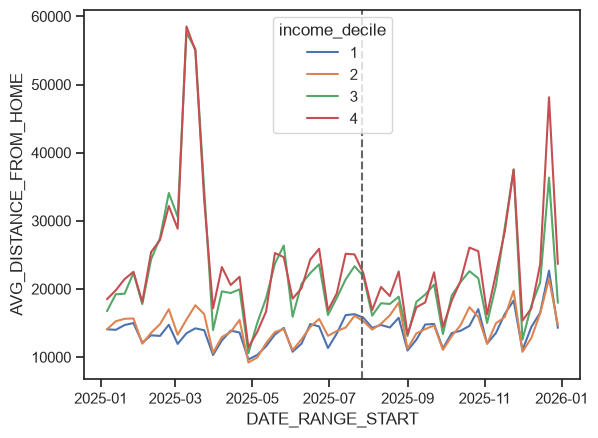

In [35]:
agg = visits_dt.join(block_groups, on="GEOID").group_by("DATE_RANGE_START", "income_decile").agg(
    pl.col("VISITOR_COUNTS").sum(),
    ((pl.col("AVG_DISTANCE_FROM_HOME") * pl.col("VISITOR_COUNTS")).sum() / pl.col("VISITOR_COUNTS").sum()).alias("AVG_DISTANCE_FROM_HOME")
).sort("income_decile")
ax = sns.lineplot(agg, x="DATE_RANGE_START", y="AVG_DISTANCE_FROM_HOME", hue="income_decile")
ax.axvline(heatwave_date, color="#666", linestyle="--")

## Visits from :area:

In [51]:
block_group_visits = con.sql("""
    WITH bg AS (
        SELECT GEOID, MSA_CODE, St_Centroid(GEOM) AS CENTROID
        FROM block_groups
        WHERE MSA_CODE = 'C4530'
    )
    SELECT 
        MSA_CODE,
        GEOID,
        DATE_RANGE_START,
        ST_Distance_Sphere(centroid, p.geom) AS DIST,
        bgv.ID_STORE,
        SUM(VISITOR_COUNT) AS VISITOR_COUNT
    FROM bg
    JOIN block_group_visits bgv ON bg.GEOID = bgv.HOME_GEOID
    JOIN pois p ON bgv.ID_STORE = p.ID_STORE
    GROUP BY 1, 2, 3, 4, 5
""").pl()
block_group_visits

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

MSA_CODE,GEOID,DATE_RANGE_START,DIST,ID_STORE,VISITOR_COUNT
str,str,datetime[μs],f64,str,"decimal[38,0]"
"""C4530""","""121030273232""",2025-01-06 00:00:00,24752.278909,"""6307743""",39
"""C4530""","""120570108053""",2025-01-06 00:00:00,10005.410577,"""3331658""",11
"""C4530""","""120570139191""",2025-01-06 00:00:00,9007.676651,"""10025709""",57
"""C4530""","""120570138072""",2025-01-06 00:00:00,13690.502786,"""10025709""",19
"""C4530""","""121030222002""",2025-01-06 00:00:00,3141.474861,"""2035617""",23
…,…,…,…,…,…
"""C4530""","""121030250152""",2025-12-29 00:00:00,1577.328406,"""9516645""",12
"""C4530""","""120570001014""",2025-12-29 00:00:00,260213.936642,"""5485547""",7
"""C4530""","""121030273331""",2025-12-29 00:00:00,552.929035,"""7940134""",252


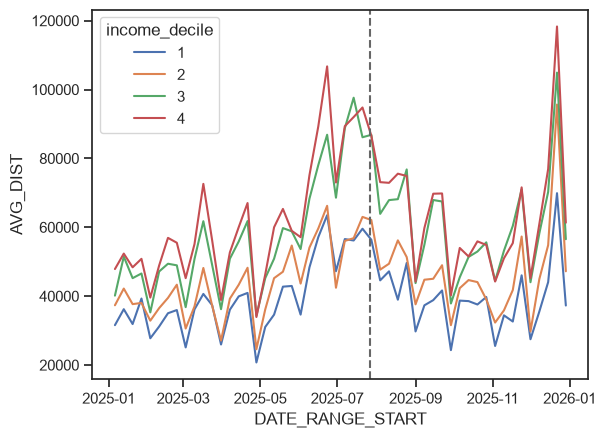

In [58]:
#agg = block_group_visits.join(block_groups, on="GEOID").group_by("DATE_RANGE_START", "income_decile").agg(
#    pl.col("VISITOR_COUNT").sum(),
#    ((pl.col("DIST") * pl.col("VISITOR_COUNT")).sum() / pl.col("VISITOR_COUNT").sum()).alias("AVG_DIST")
#).sort("income_decile")

ax = sns.lineplot(agg, x="DATE_RANGE_START", y="AVG_DIST", hue="income_decile")
ax.axvline(heatwave_date, color="#666", linestyle="--")

In [81]:
closest_date = block_group_visits.filter(pl.col("DATE_RANGE_START") <= heatwave_date)["DATE_RANGE_START"].max()
minus_three_weeks = heatwave_date - timedelta(days=3*7)
baseline_block_group_visits = block_group_visits.filter(
    (pl.col("DATE_RANGE_START") >= minus_three_weeks) & (pl.col("DATE_RANGE_START") <= heatwave_date))

In [85]:
baseline_block_group_visits.group_by("GEO_ID")

MSA_CODE,GEOID,DATE_RANGE_START,DIST,ID_STORE,VISITOR_COUNT
str,str,datetime[μs],f64,str,"decimal[38,0]"
"""C4530""","""121030244063""",2025-07-07 00:00:00,9873.89167,"""13452386""",19
"""C4530""","""121010324011""",2025-07-07 00:00:00,8859.216373,"""3331650""",86
"""C4530""","""121030250131""",2025-07-07 00:00:00,201949.410715,"""12133234""",39
"""C4530""","""120570120011""",2025-07-07 00:00:00,129338.720484,"""11097602""",6
"""C4530""","""121030269092""",2025-07-07 00:00:00,1359.3216,"""4233813""",19
…,…,…,…,…,…
"""C4530""","""121030256032""",2025-07-21 00:00:00,709.84024,"""11368965""",307
"""C4530""","""121030272062""",2025-07-21 00:00:00,25188.9792,"""5484857""",5
"""C4530""","""120570116033""",2025-07-21 00:00:00,2.7025e6,"""5118850""",42
